In [1]:
import logging
import os
import re
from pathlib import Path

import pandas as pd
import numpy as np
from napistu.utils import load_pickle, save_pickle
import matplotlib.pyplot as plt
import seaborn as sns

from napistu_torch.load.foundation_models import AttendedEmbeddingsSet, FoundationModels, _get_disk_name
from napistu_torch.utils.tensor_utils import (
    compute_correlation_matrix
)
from napistu_torch.utils.torch_utils import (
    cleanup_tensors,
    ensure_device,
)
from napistu_torch.load.constants import MODEL_NICE_NAMES
from napistu_torch.utils.statistics import compare_top_k_union_ranks
from napistu_torch.utils.tensor_utils import compute_correlation_matrix
from napistu_torch.utils.pd_utils import reorder_multindex_by_categorical_and_numeric
from napistu_torch.visualization.heatmaps import plot_heatmap


# Configure logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s:%(name)s:%(message)s')
logger = logging.getLogger(__name__)

# how to aggregate across layers
CONSENSUS_METHOD = "sum"
# select max absolute value for top-hits (True) or max raw value (False)
BY_ABSOLUTE_VALUE = False
VERBOSE = True
TOP_K = 10000
IGNORE_SELF_ATTENTION = True # ignore self-attention (from_gene == to_gene) when comparing attention ranks
DEVICE = ensure_device(None, allow_autoselect=True)
OVERWRITE = False # used for caching

CACHE_DIR = Path("~/Desktop/DATA").expanduser()
EMBEDDING_TYPE = "expression"
EMBEDDING_DATASET = "efthymiou2025"
EMBEDDING_CATEGORY = "adipocyte (0)"

if EMBEDDING_TYPE == "expression":
    def to_filename(s: str) -> str:
        s = re.sub(r'[^\w\s-]', '', s)  # remove chars that aren't word chars, spaces, or hyphens
        s = re.sub(r'\s+', '_', s)      # replace whitespace with underscores
        return s.strip('-_')

    CACHE_FILE = f"attended_embeddings_set_{EMBEDDING_DATASET}_{to_filename(EMBEDDING_CATEGORY)}.pkl"
elif EMBEDDING_TYPE == "static":
    CACHE_FILE = "attended_embeddings_set_static.pkl"
else:
    raise ValueError(f"Invalid EMBEDDING_TYPE: {EMBEDDING_TYPE}")

COMPARISONS_CACHE = CACHE_DIR / CACHE_FILE
OUTPUT_DIR = "output" # where extracted foundation model weights are stored
model_names = list(MODEL_NICE_NAMES.values()) # models of interest
model_prefixes = [_get_disk_name(model_name, model_variant) for model_name, model_variant in MODEL_NICE_NAMES]


In [2]:
# load each model's weights, gene annotations, and model metadata
models = FoundationModels.load_multiple(OUTPUT_DIR, model_prefixes)

INFO:napistu_torch.load.foundation_models:Loading weights (AIDOCell_aido_cell_3m_weights.npz) and metadata (  AIDOCell_aido_cell_3m_metadata.json) from output_dir (output)
INFO:napistu_torch.load.foundation_models:Successfully loaded all results
INFO:napistu_torch.load.foundation_models:Loading 18 dataset gene embeddings
INFO:napistu_torch.load.foundation_models:Found 18156 common genes across 18 embeddings (ontology: 'ensembl_gene')
INFO:napistu_torch.load.foundation_models:Loading weights (AIDOCell_aido_cell_10m_weights.npz) and metadata (  AIDOCell_aido_cell_10m_metadata.json) from output_dir (output)
INFO:napistu_torch.load.foundation_models:Successfully loaded all results
INFO:napistu_torch.load.foundation_models:Loading 18 dataset gene embeddings
INFO:napistu_torch.load.foundation_models:Found 18156 common genes across 18 embeddings (ontology: 'ensembl_gene')
INFO:napistu_torch.load.foundation_models:Loading weights (AIDOCell_aido_cell_100m_weights.npz) and metadata (  AIDOCell_a

In [3]:
from napistu_torch.napistu_data_store import NapistuDataStore
from napistu.constants import BQB_DEFINING_ATTRS_LOOSE
from napistu_torch.load.constants import DEFAULT_ARTIFACTS_NAMES

STORE_DIR = os.path.expanduser("~/Desktop/EXPERIMENTS/.store")
napistu_data_store = NapistuDataStore(STORE_DIR)
species_identifiers = (
    napistu_data_store.load_pandas_df(DEFAULT_ARTIFACTS_NAMES.SPECIES_IDENTIFIERS)
    .query("bqb in @BQB_DEFINING_ATTRS_LOOSE") # filter complexes (which would could contain a protein with a BQB_HAS_PART qualifier)
)
# map from vertex names (compartmentalized species IDs) to species ids (sids)
name_to_sid_map = napistu_data_store.load_pandas_df(DEFAULT_ARTIFACTS_NAMES.NAME_TO_SID_MAP).reset_index()

from napistu.constants import SBML_DFS
from napistu.ontologies.constants import ONTOLOGIES
from napistu.network.constants import NAPISTU_GRAPH_VERTICES

EXPECTED_NAME_TO_SID_MAP_COLUMNS = {SBML_DFS.S_ID, NAPISTU_GRAPH_VERTICES.NAME}


/Users/sean/Desktop/GITHUB/napistu/lib/napistu-scrapyard/scraps/pytorch/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:napistu_torch.napistu_data_store:Loading pandas DataFrame from /Users/sean/Desktop/EXPERIMENTS/.store/pandas_dfs/species_identifiers.parquet
INFO:napistu_torch.napistu_data_store:Loading pandas DataFrame from /Users/sean/Desktop/EXPERIMENTS/.store/pandas_dfs/name_to_sid_map.parquet


In [4]:
# only look at the common vocab to shrink the space from ~60K x 60K to ~20K x 20K

from typing import Dict, Any, Tuple, List

def compare_foundation_models(
    attended_embeddings_set: AttendedEmbeddingsSet,
    top_k: int,
    consensus_method: str,
    by_absolute_value: bool,
    ignore_self_attention: bool,
    verbose: bool,
) -> Dict[str, Any]:

    # precalculate and cache operations that take more than a minute or so
    comparisons = dict()

    # gene embedding correlations
    logger.info("Calculating gene embedding correlations...")
    comparisons["gene_embedding_correlations"] = attended_embeddings_set.embeddings_set.compare_embeddings(verbose = verbose)

    # within model layer x layer comparisons (correlations and rank agreement)
    logger.info("Calculating within model layer x layer comparisons...")
    comparisons["model_layer_correlations"], comparisons["model_layer_rank_agreement"] = (
        _get_within_model_layer_x_layer_comparison(attended_embeddings_set, top_k, ignore_self_attention, by_absolute_value, verbose)
    )

    # cross model x layer top attentions
    logger.info("Calculating cross model x layer top attentions...")
    comparisons["cross_model_x_layer_top_attentions"] = (
        attended_embeddings_set.get_top_attentions(
            k = top_k,
            by_absolute_value = by_absolute_value,
            reextract_union = True,
            compute_ranks = True,
            ignore_self_attention = ignore_self_attention,
            verbose = verbose,
    ))

    logger.info("Comparing ranks of topK attentions in one model/layer to all other models/layers...")
    n_genes = attended_embeddings_set.n_common_genes
    comparisons["cross_model_x_layer_rank_agreement"] = compare_top_k_union_ranks(
        comparisons["cross_model_x_layer_top_attentions"],
        grouping_vars = ["model", "layer"],
        defining_vars = ["from_gene", "to_gene"],
        max_rank = n_genes ** 2,
        top_k = TOP_K,
        rank_col = "attention_rank"
    )

    logger.info("Calculating cross model consensus top attentions...")
    comparisons["cross_model_consensus_top_attentions"] = (
        attended_embeddings_set.get_consensus_top_attentions(
            k = top_k,
            consensus_method = consensus_method,
            by_absolute_value = by_absolute_value,
            reextract_union = True,
            compute_ranks = True,
            ignore_self_attention = ignore_self_attention,
            verbose = verbose,
    ))

    comparisons["settings"] = {
        "top_k": top_k,
        "consensus_method": consensus_method,
        "by_absolute_value": by_absolute_value,
        "ignore_self_attention": ignore_self_attention,
        "embedding_keys": attended_embeddings_set.embedding_keys
    }

    return comparisons


def _get_within_model_layer_x_layer_comparison(
    attended_embeddings_set: AttendedEmbeddingsSet,
    top_k: int,
    ignore_self_attention: bool,
    by_absolute_value: bool,
    verbose: bool,
) -> Tuple[Dict[str, Any], Dict[str, Any]]:

    if not isinstance(attended_embeddings_set, AttendedEmbeddingsSet):
        raise ValueError("attended_embeddings_set must be an instance of AttendedEmbeddingsSet")

    model_layer_correlations = {}
    model_layer_rank_agreement = {}

    for an_attended_embedding in attended_embeddings_set.attended_embeddings.values():

        model_name = an_attended_embedding.model_name
        logger.info(f"Summarizing cross-layer attention consistency for {model_name}...")

        model_layer_correlations[model_name], model_layer_rank_agreement[model_name] = an_attended_embedding.compare_layer_attention_consistency(
            top_k = top_k,
            ignore_self_attention = ignore_self_attention,
            by_absolute_value = by_absolute_value,
            verbose = verbose
        )
        
    return model_layer_correlations, model_layer_rank_agreement

def validate_results_against_current_settings(
    results: Dict[str, Any],
    top_k: int,
    consensus_method: str,
    by_absolute_value: bool,
    ignore_self_attention: bool,
    embedding_keys: List[str],
) -> None:

    # check compatibility between the loaded results and the current settings
    if top_k != results["settings"]["top_k"]:
        logger.warning(f"TOP_K mismatch: {TOP_K} != {results['settings']['top_k']}")
    if consensus_method != results["settings"]["consensus_method"]:
        logger.warning(f"CONSENSUS_METHOD mismatch: {CONSENSUS_METHOD} != {results['settings']['consensus_method']}")
    if by_absolute_value != results["settings"]["by_absolute_value"]:
        logger.warning(f"BY_ABSOLUTE_VALUE mismatch: {BY_ABSOLUTE_VALUE} != {results['settings']['by_absolute_value']}")
    if ignore_self_attention != results["settings"]["ignore_self_attention"]:
        logger.warning(f"IGNORE_SELF_ATTENTION mismatch: {IGNORE_SELF_ATTENTION} != {results['settings']['ignore_self_attention']}")
    if set(embedding_keys) != set(results["settings"]["embedding_keys"]):
        extra_models = set(results["settings"]["embedding_keys"]) - set(embedding_keys)
        missing_models = set(embedding_keys) - set(results["settings"]["embedding_keys"])
        logger.warning(f"Extra models: {extra_models}")
        logger.warning(f"Missing models: {missing_models}")


In [5]:
if EMBEDDING_TYPE == "expression":
    attended_embeddings = AttendedEmbeddingsSet.from_expression(models, EMBEDDING_DATASET, EMBEDDING_CATEGORY)
elif EMBEDDING_TYPE == "static":
    attended_embeddings = AttendedEmbeddingsSet.from_static(models, align_on=ONTOLOGIES.ENSEMBL_GENE)
else:
    raise ValueError(f"Invalid EMBEDDING_TYPE: {EMBEDDING_TYPE}")

if os.path.isfile(COMPARISONS_CACHE) and not OVERWRITE:
    comparisons = load_pickle(COMPARISONS_CACHE)
    validate_results_against_current_settings(comparisons, TOP_K, CONSENSUS_METHOD, BY_ABSOLUTE_VALUE, IGNORE_SELF_ATTENTION, attended_embeddings.embedding_keys)
else:
    comparisons = compare_foundation_models(attended_embeddings, TOP_K, CONSENSUS_METHOD, BY_ABSOLUTE_VALUE, IGNORE_SELF_ATTENTION, VERBOSE)
    logger.info(f"Saving results to {COMPARISONS_CACHE}")
    save_pickle(COMPARISONS_CACHE, comparisons)

model_order = attended_embeddings.embedding_keys

INFO:napistu_torch.load.foundation_models:Found 744 common genes across 8 embeddings (ontology: 'ensembl_gene')


## Compare embeddings

To assess whether the embeddings are organizing genes in a similar way, I directly compared them. Since their embedding dimensions differ I decided to generate a gene-gene distance matrix (using cosine distance) for each embedding and then I compared all pairs of distance matrices using Spearman correlation.

The highest concordance is between scGPT and scPRINT (rho ~ 0.28) while AIDO.Cell's gene embeddings show low concordance with the other models, and between the different AIDO.Cell models (i.e., the 3M, 10M, and 100M cell models). This may just be a feature of AIDO.Cell's architecture since it uses gene-level positional embeddings which may not actual learn gene-gene similarity.

In [6]:
embeddings_comparisons = comparisons["gene_embedding_correlations"]

wide_embeddings_comparisons = (
    pd.DataFrame(list(embeddings_comparisons.items()), columns=['model', 'rho'])
    .assign(
        model1=lambda df: df['model'].str.split("_vs_", expand=True)[0],
        model2=lambda df: df['model'].str.split("_vs_", expand=True)[1]
    )
    .pivot(index='model2', columns='model1', values='rho')
    .reindex(index=model_order, columns=model_order)
    .dropna(axis=0, how = "all")
    .dropna(axis=1, how = "all")
)

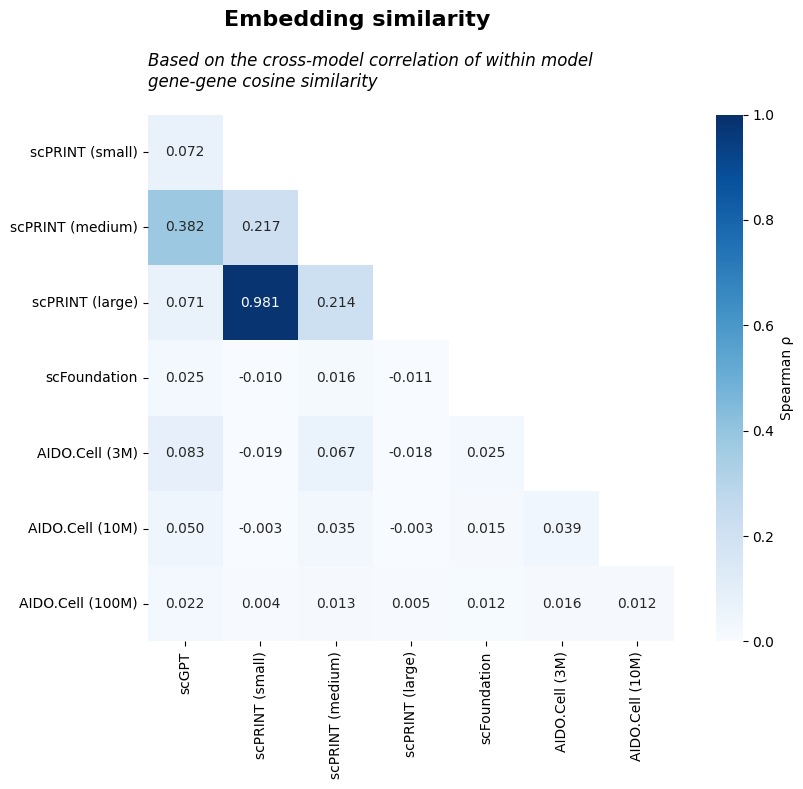

In [7]:
plot_heatmap(
    wide_embeddings_comparisons,
    mask_upper_triangle=True,
    vmax=1,
    vmin=0,
    cbar_label='Spearman ρ',
    suptitle="Embedding similarity",
    title="Based on the cross-model correlation of within model\ngene-gene cosine similarity",
    title_size=12,
    square=True,
    title_fontstyle="italic",
    title_fontweight="normal",
)

plt.show()

## Compare attention

Next, I want to compare the gene-gene attention probabilities (the softmax, makes these a probability distribution for each column) to see how pairs of genes are attending to each other.

### Working with attention summaries

Since Foundation models all use Transformer-based architectural with multiple multi-headed attention layers we can summarize the attention mechanisms either layer-wise or as an aggregate over all layers.

#### From a single layers

At the level of an individual layer, a couple of useful summaries are:

- the raw attention patterns: (gene, gene)
- top-k attention pairs

In [8]:
A_MODEL = "scPRINT (small)"
A_LAYER = 3
ae = attended_embeddings[A_MODEL]

# calculate one layer's attention pattern
attention = ae.compute_attention(layer_idx = A_LAYER, apply_softmax = False)
print(attention.shape)

# pulling out its top-k attention pairs
top_k_attention_edges = ae.get_top_attentions(
    k = TOP_K,
    layer_indices = A_LAYER,
    apply_softmax = False,
    by_absolute_value = BY_ABSOLUTE_VALUE,
)

display(top_k_attention_edges.head())
cleanup_tensors(attention, top_k_attention_edges)


(744, 744)


,layer,from_idx,to_idx,from_gene,to_gene,attention
0,3,347,431,ENSG00000159398,ENSG00000169688,0.046020
1,3,354,431,ENSG00000161016,ENSG00000169688,0.045954
2,3,87,431,ENSG00000105679,ENSG00000169688,0.044996
3,3,354,678,ENSG00000161016,ENSG00000205364,0.044896
4,3,354,145,ENSG00000161016,ENSG00000118181,0.044773


Either of these summaries can be rolled up across layers but before doing so we can evaluate whether cross-layer summaries are loosly consistent.

To explore this I'll pull out the top-attention pairs for each layer and compare them across the layers within the same model.

For a single model this can be done with:

```python
# get top-k attention edges for each layer
top_k_attention_edges = (
    attended_embeddings[A_MODEL]
    .get_top_attentions(
        k = 10000,
        by_absolute_value = BY_ABSOLUTE_VALUE,
    )
)

# (gene x gene) summary as attention[arg-max(|attention|)]
(
    attended_embeddings[A_MODEL]
    .compute_consensus_attention(
        consensus_method = CONSENSUS_METHOD
    )
)
```

But, the `FoundationModels` class has convenience methods for aggregating summaries from multiple models.

Here, we'll use the `FoundationModels`'s `get_top_attentions()` to pull out each model x layer's top-K attention scores. A similar method, which will be used later, `get_max_attentions` can be used to create a 3D Tensor of each model's (gene x gene) consensus attention scores.


## Within model - across layers

### Looking at top attention pairs from each layer and model

1. define attention probabilities for each layer (I x I). Where is I is the length and ordering of `common_identifiers`
2. select the N greatest attention probabilities from each layer returning the row and column indices and the attention probability
3. aggregate across all layers and models and store results as a pd.DataFrame
4. rename row/column indices as ensembl genes using `common_identifiers`
5. for each model cound distinct row (from) and column (to) pairs
6. pivot so there is 1 row per from-to edge and columns represent counts of each pair in the top attentions of each model




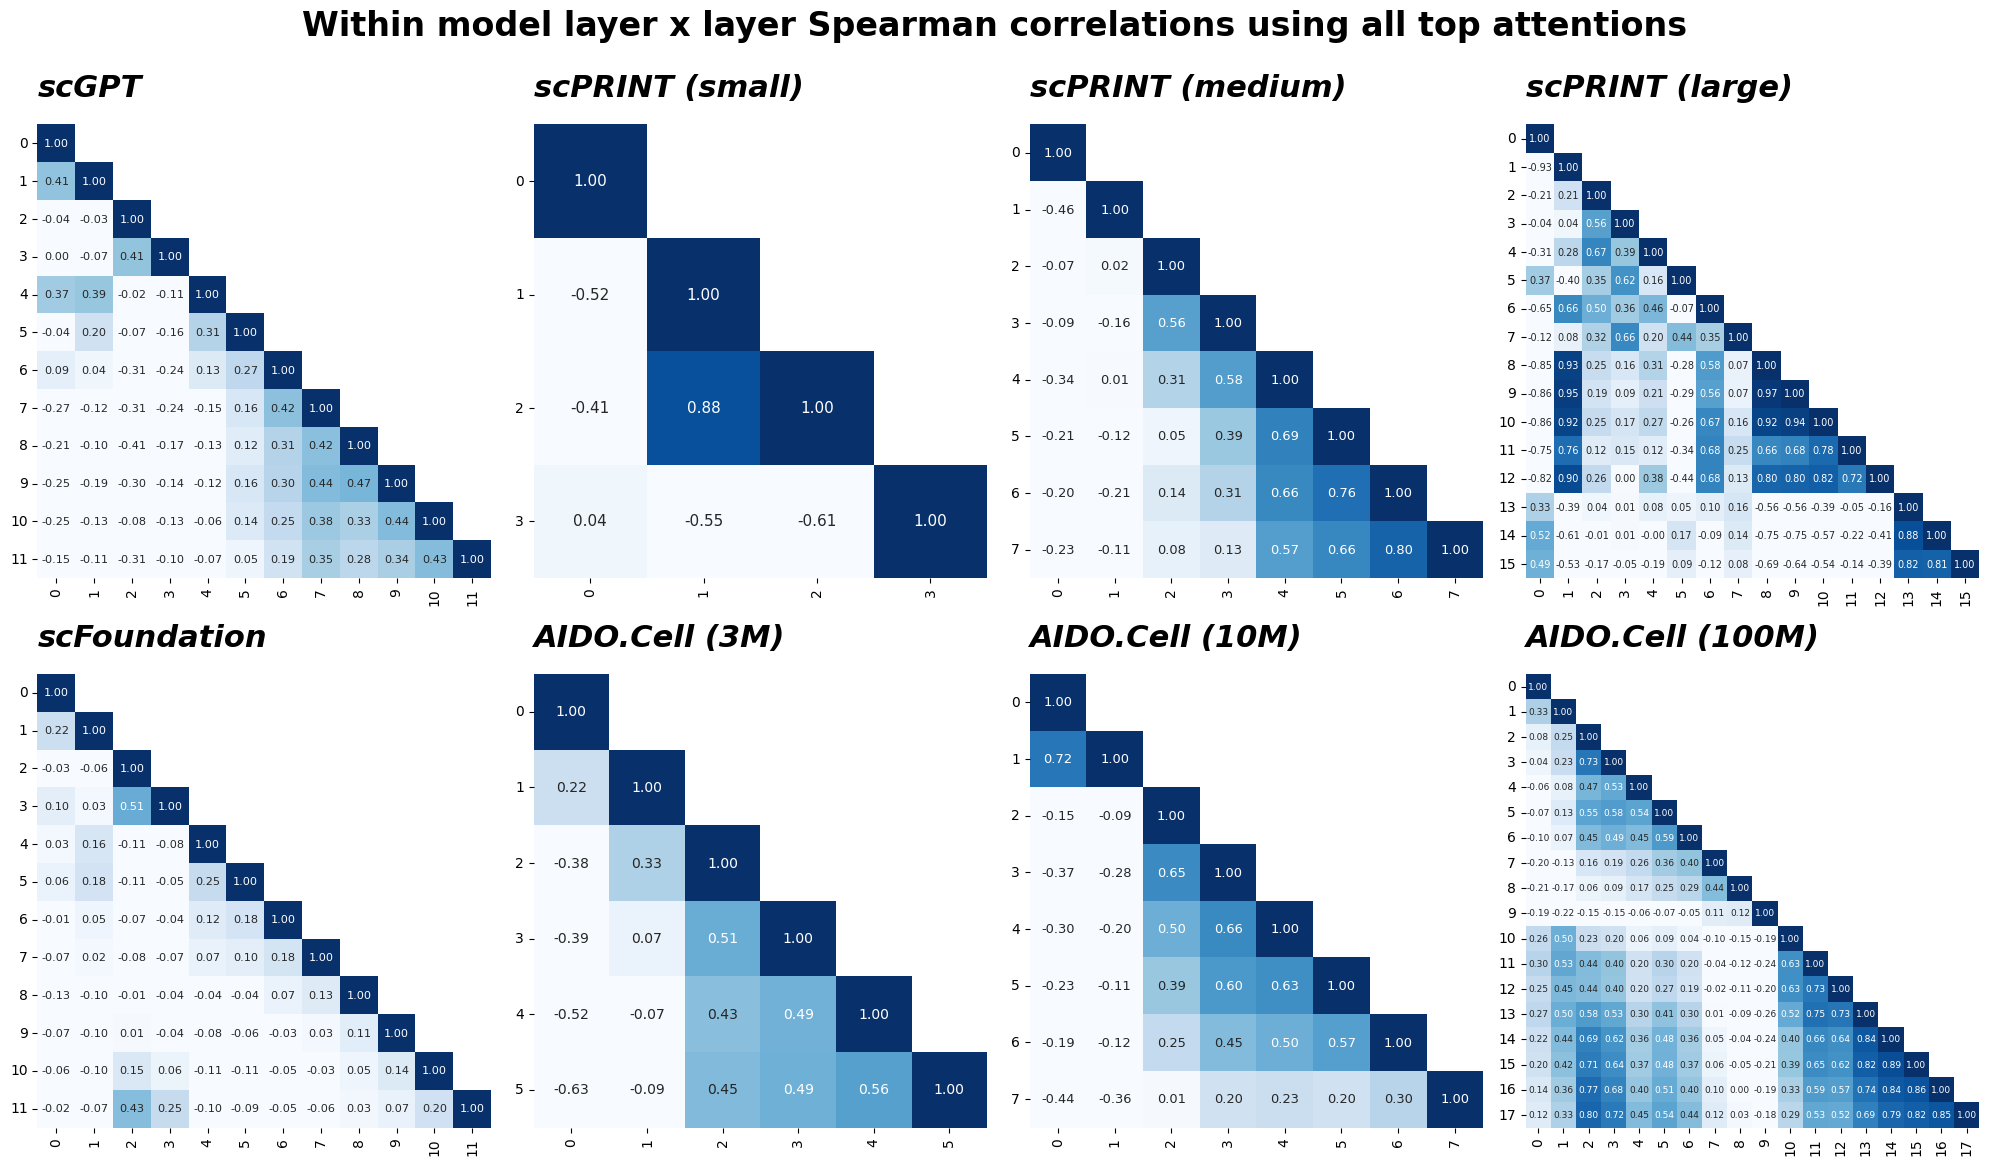

In [9]:
model_layer_correlations = comparisons["model_layer_correlations"]

fig, axes = plt.subplots(2, 4, figsize=(20, 12))
axes = axes.flatten()

for idx, model_name in enumerate(model_order):

    data = model_layer_correlations[model_name]
    annot_size = 15 - 2*np.sqrt(data.shape[0])

    plot_heatmap(
        data,
        row_labels = range(models.get_model(model_name).n_layers),
        title=model_name,
        cbar=False,
        fmt='.2f',
        vmax=1,
        vmin=0,
        cbar_label='Spearman ρ',
        mask_upper_triangle=True,
        square=True,
        title_size=22,
        annot_size=annot_size,
        title_fontstyle="italic",
        ax=axes[idx],
    )

plt.suptitle("Within model layer x layer Spearman correlations using all top attentions", fontsize=24, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

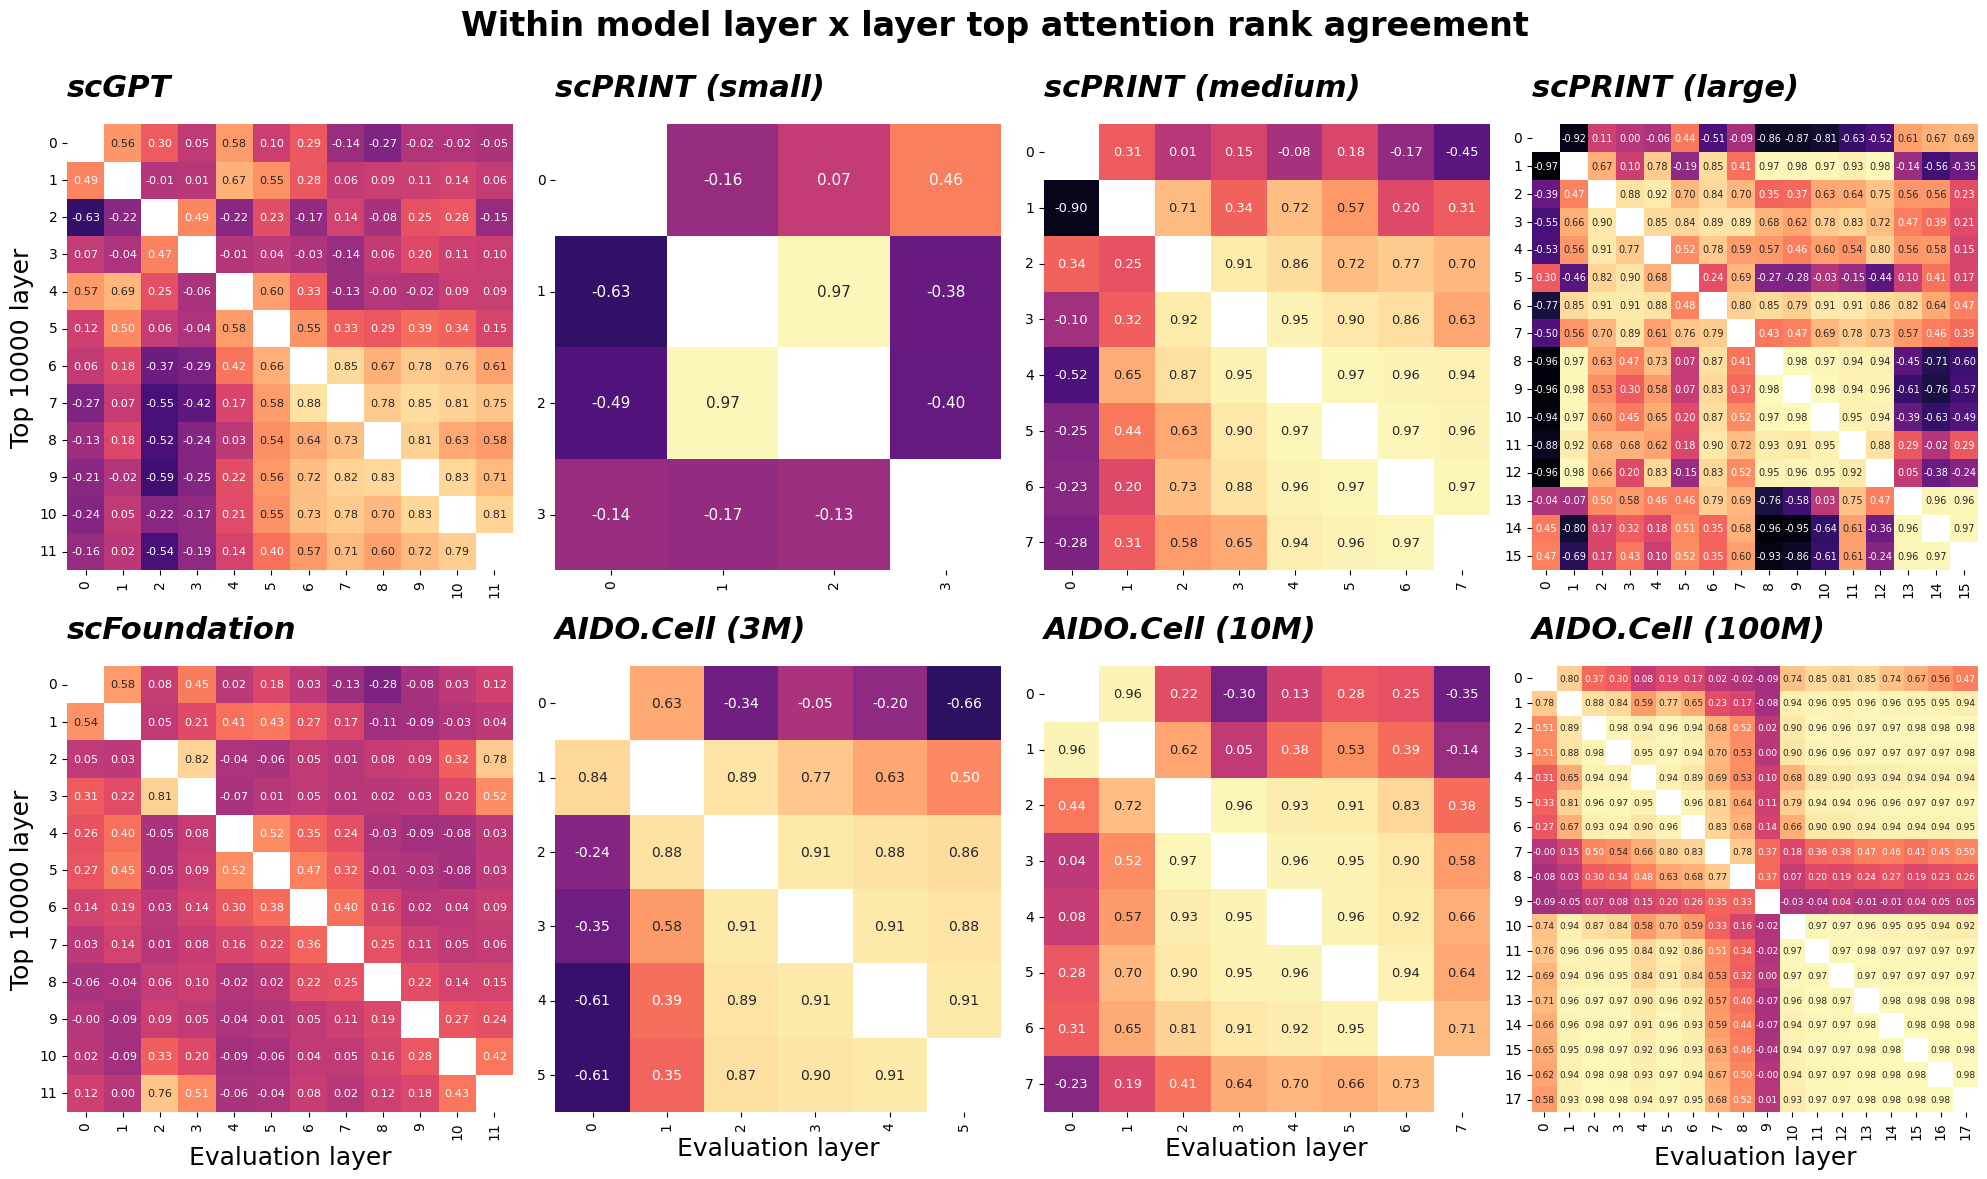

In [10]:
model_layer_rank_agreement = comparisons["model_layer_rank_agreement"]

N_COLUMNS = 4
fig, axes = plt.subplots(2, N_COLUMNS, figsize=(20, 12))
axes = axes.flatten()

for idx, model_name in enumerate(model_order):

    conditional_quantiles = (0.5 + -1 * model_layer_rank_agreement[model_name].pivot(index = "query_layer", columns = "eval_layer", values = "median_quantile"))*2

    x_title = "Evaluation layer" if idx >= N_COLUMNS else None
    y_title = f"Top {TOP_K} layer" if idx % N_COLUMNS == 0 else None
    annot_size = 15 - 2*np.sqrt(conditional_quantiles.shape[0])
    
    plot_heatmap(
        conditional_quantiles,
        row_labels = range(models.get_model(model_name).n_layers),
        title=model_name,
        xlabel=x_title,
        ylabel=y_title,
        cmap='magma',
        cbar=False,
        fmt='.2f',
        vmax=1,
        vmin=-1,
        cbar_label='Spearman ρ',
        mask_upper_triangle=False,
        square=True,
        title_size=22,
        axis_title_size=18,
        annot_size=annot_size,
        title_fontstyle="italic",
        ax=axes[idx],
    )

plt.suptitle("Within model layer x layer top attention rank agreement", fontsize=24, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## Across models (all layers)

In [11]:
cross_model_top_attentions = comparisons["cross_model_x_layer_top_attentions"]

# look at the top attentions for each model/layer across all models and layers
wide_consistent_attentions = (
    cross_model_top_attentions.pivot(
        index = ["from_gene", "to_gene"],
        columns = ["model", "layer"],
        values = "attention"
    )
)

# wide_consistent_attentions = (wide_consistent_attentions.T - wide_consistent_attentions.T.apply("mean", axis = 0)).T

model_layer_labels = [f"{model}-{layer}" for model, layer in wide_consistent_attentions.columns]

cross_model_attention_corr = compute_correlation_matrix(wide_consistent_attentions.to_numpy(), verbose=True)

# mask within-model block diagonal
model_col_values = wide_consistent_attentions.columns.get_level_values(0)

# Create mask where models match (True = mask/hide these values)
mask = model_col_values.to_numpy()[:, None] == model_col_values.to_numpy()[None, :]
assert mask.shape == cross_model_attention_corr.shape

INFO:napistu_torch.utils.tensor_utils:Computing Spearman correlation for 317209 samples and 84 features on device mps


### layer x layer attention correlation

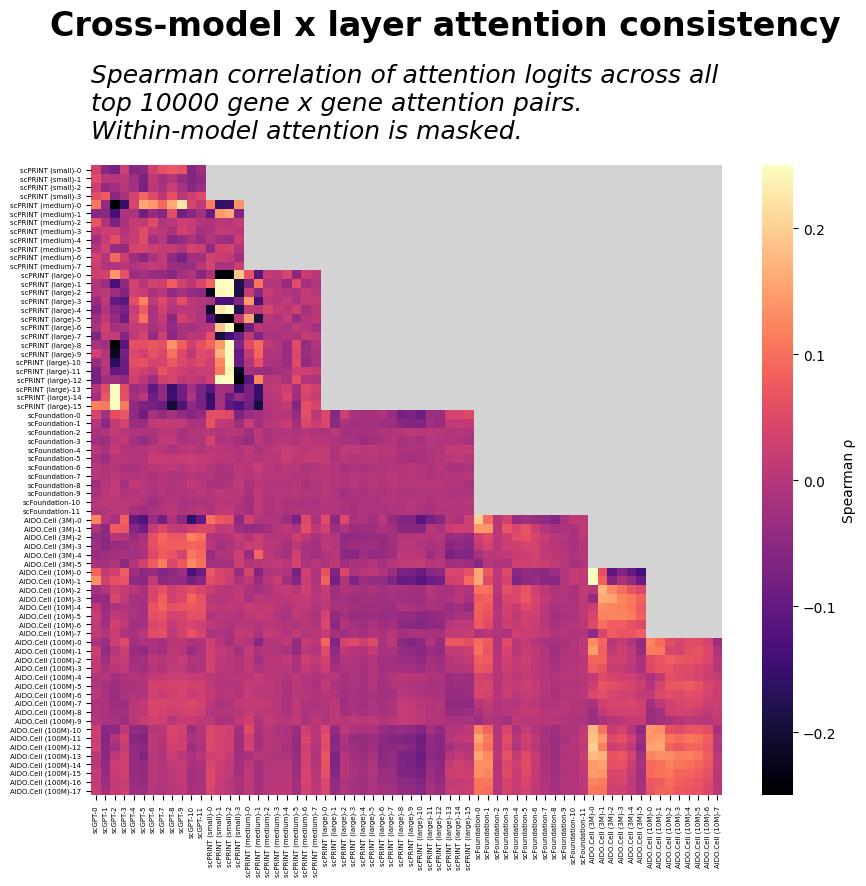

In [12]:
upper_tri_mask = np.triu(np.ones_like(mask, dtype=bool), k=1)
combined_mask = mask | upper_tri_mask

# Find rows and columns that are completely masked (all True)
rows_to_keep = ~combined_mask.all(axis=1)  # Keep rows that have at least one False
cols_to_keep = ~combined_mask.all(axis=0)  # Keep columns that have at least one False

# Filter your data and mask
non_null_cross_model_attention_corr = cross_model_attention_corr[rows_to_keep][:, cols_to_keep]
filtered_mask = combined_mask[rows_to_keep][:, cols_to_keep]

# If you have labels, filter those too
filtered_row_labels = [label for i, label in enumerate(model_layer_labels) if rows_to_keep[i]]
filtered_col_labels = [label for i, label in enumerate(model_layer_labels) if cols_to_keep[i]]

plot_heatmap(
    non_null_cross_model_attention_corr,
    row_labels = filtered_row_labels,
    column_labels = filtered_col_labels,
    suptitle="Cross-model x layer attention consistency",
    title=f"Spearman correlation of attention logits across all\ntop {TOP_K} gene x gene attention pairs.\nWithin-model attention is masked.",
    cmap='magma',
    cbar=True,
    fmt='.2f',
    vmax=0.25,
    vmin=-0.25,
    cbar_label='Spearman ρ',
    mask = filtered_mask,
    mask_color='lightgray',
    annot=False,
    tick_label_size=5,
    suptitle_size=24,
    title_size=18,
    title_fontstyle="italic",
    title_fontweight="normal",
    figsize=(9, 9)
)

plt.show()

In [13]:
model_layer_labels_df = pd.DataFrame(
    wide_consistent_attentions.columns.tolist(),
    columns = ["model", "layer"]
)
model_layer_labels_df["label"] = model_layer_labels

triplet_df = (
    pd.DataFrame(
        cross_model_attention_corr,
        index = model_layer_labels,
        columns = model_layer_labels
    )
    .stack()
    .reset_index(name='value')
    .rename(columns={'level_0': 'row', 'level_1': 'col'})
    .query('row > col')  # Lower triangle excluding diagonal
    # expand layer metadata
    .merge(model_layer_labels_df.rename(columns = {"model" : "model1", "layer" : "layer1", "label" : "row"}))
    .merge(model_layer_labels_df.rename(columns = {"model" : "model2", "layer" : "layer2", "label" : "col"}))
)

triplet_df.query('model1 != model2').sort_values('value', ascending = True).head(10)

,row,col,value,model1,layer1,model2,layer2
777,scPRINT (small)-2,scPRINT (large)-0,-0.519997,scPRINT (small),2,scPRINT (large),0
695,scPRINT (small)-1,scPRINT (large)-0,-0.368233,scPRINT (small),1,scPRINT (large),0
922,scPRINT (medium)-0,scGPT-2,-0.314202,scPRINT (medium),0,scGPT,2
866,scPRINT (small)-3,scPRINT (large)-6,-0.311796,scPRINT (small),3,scPRINT (large),6
782,scPRINT (small)-2,scPRINT (large)-5,-0.272229,scPRINT (small),2,scPRINT (large),5
2038,scPRINT (large)-8,scGPT-2,-0.261615,scPRINT (large),8,scGPT,2
872,scPRINT (small)-3,scPRINT (large)-12,-0.260948,scPRINT (small),3,scPRINT (large),12
616,scPRINT (small)-0,scPRINT (large)-2,-0.224330,scPRINT (small),0,scPRINT (large),2
700,scPRINT (small)-1,scPRINT (large)-5,-0.222883,scPRINT (small),1,scPRINT (large),5
2108,scPRINT (large)-9,scGPT-2,-0.219014,scPRINT (large),9,scGPT,2


### Layer x layer rank consistency 

In [14]:
model_x_layer_rank_agreement = comparisons["cross_model_x_layer_rank_agreement"]

# [0,1] low quantiles are more consistent (ranks in attent B | top in A)
raw_conditional_quantiles = (
    model_x_layer_rank_agreement
    .pivot(
        index = ["query_model", "query_layer"],
        columns = ["eval_model", "eval_layer"],
        values = "median_quantile"
    )
)

# Reorder to match model/layer ordering from wide_consistent_attentions
reordered_index = reorder_multindex_by_categorical_and_numeric(
    raw_conditional_quantiles.index,
    categorical_order=model_order,
    categorical_level=0,  # query_model
    numeric_level=1       # query_layer
)

# Get categorical order (model order) from reference
# Reorder index and columns
raw_conditional_quantiles = raw_conditional_quantiles.reindex(
    index=reordered_index,
    columns=reordered_index
)

# [0,1] -> [-1,1] with values near 1 being more consistent
conditional_quantiles = (0.5 + -1 * raw_conditional_quantiles)*2

# mask within-model block diagonal
model_col_values = conditional_quantiles.columns.get_level_values(0)

# Create mask where models match (True = mask/hide these values)
mask = model_col_values.to_numpy()[:, None] == model_col_values.to_numpy()[None, :]


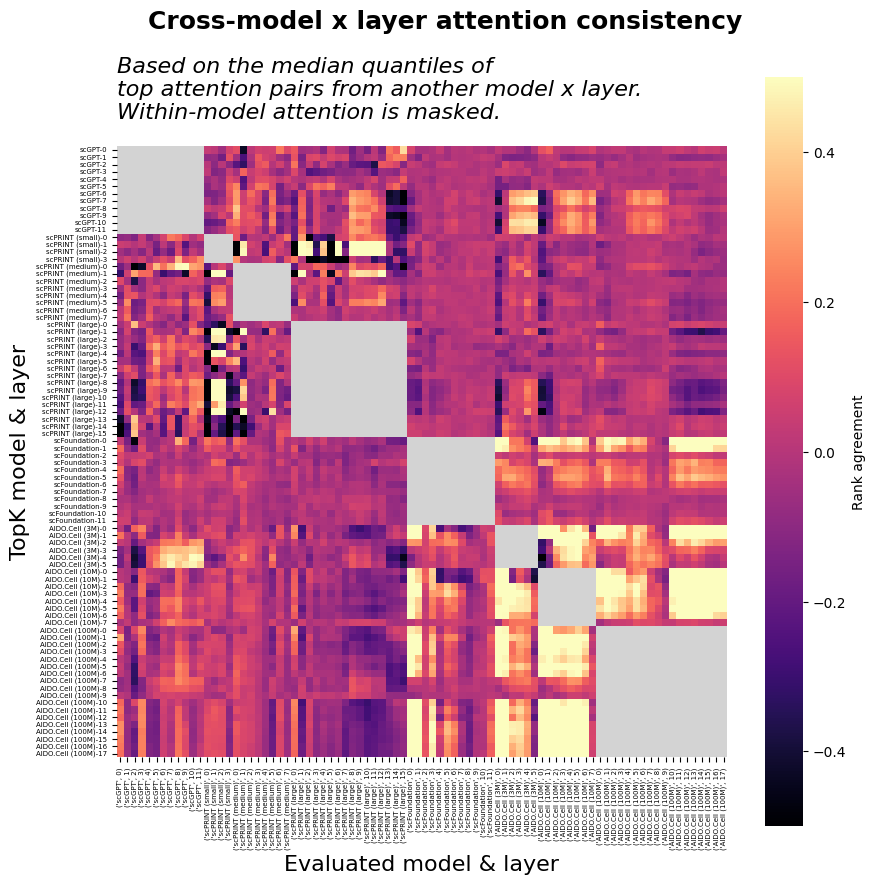

In [15]:
model_layer_labels = [f"{model}-{layer}" for model, layer in conditional_quantiles.columns]

plot_heatmap(
    conditional_quantiles,
    row_labels = model_layer_labels,
    suptitle="Cross-model x layer attention consistency",
    title="Based on the median quantiles of\ntop attention pairs from another model x layer.\nWithin-model attention is masked.",
    xlabel = "Evaluated model & layer",
    ylabel = "TopK model & layer",
    cmap='magma',
    cbar=True,
    fmt='.2f',
    vmax=0.5,
    vmin=-0.5,
    cbar_label='Rank agreement',
    mask = mask,
    mask_upper_triangle=False,
    mask_color='lightgray',
    annot=False,
    square=True,
    suptitle_size=18,
    title_size=16,
    axis_title_size=16,
    tick_label_size=5,
    title_fontstyle="italic",
    title_fontweight="normal",
    figsize=(9, 9)
)

plt.show()

In [16]:
max_cross_model_layer_agreement = model_x_layer_rank_agreement.query('query_model != eval_model').sort_values('median_quantile', ascending = True).groupby(['eval_model', 'query_model']).first()
max_cross_model_layer_agreement

query_layer  eval_layer  mean_quantile  \
eval_model       query_model                                                
AIDO.Cell (100M) AIDO.Cell (10M)             2          13       0.226623   
                 AIDO.Cell (3M)              0          12       0.214326   
                 scFoundation                0          13       0.235792   
                 scGPT                       7           7       0.388870   
                 scPRINT (large)             3           0       0.442887   
                 scPRINT (medium)            0           7       0.455705   
                 scPRINT (small)             0           0       0.480291   
AIDO.Cell (10M)  AIDO.Cell (100M)           12           1       0.152614   
                 AIDO.Cell (3M)              0           1       0.116481   
                 scFoundation                0           1       0.230771   
                 scGPT                       7           4       0.369190   
                 scPRINT (large)            14           3       0.464715   
                 scPRINT (medium)            0           4       0.452858   
                 scPRINT (small)             3           7       0.468274   
AIDO.Cell (3M)   AIDO.Cell (100M)           12           0       0.139718   
                 AIDO.Cell (10M)             1           0       0.125349   
                 scFoundation                0           0       0.208723   
                 scGPT                       7           5       0.326790   
                 scPRINT (large)            12           4       0.405937   
                 scPRINT (medium)            1           4       0.412996   
                 scPRINT (small)             3           2       0.453318   
scFoundation     AIDO.Cell (100M)           13           0       0.195704   
                 AIDO.Cell (10M)             1           0       0.241388   
                 AIDO.Cell (3M)              0           0       0.222043   
                 scGPT                      10           6       0.463994   
                 scPRINT (large)             0           0       0.473537   
                 scPRINT (medium)            3           3       0.475836   
                 scPRINT (small)             1           0       0.459927   
scGPT            AIDO.Cell (100M)            1           0       0.395554   
                 AIDO.Cell (10M)             7           7       0.405261   
                 AIDO.Cell (3M)              4          10       0.328704   
                 scFoundation                0           8       0.379654   
                 scPRINT (large)            13           2       0.308154   
                 scPRINT (medium)            0           9       0.313015   
                 scPRINT (small)             3           8       0.368275   
scPRINT (large)  AIDO.Cell (100M)            0           0       0.381000   
                 AIDO.Cell (10M)             5           0       0.431673   
                 AIDO.Cell (3M)              0           0       0.402092   
                 scFoundation                1           0       0.455180   
                 scGPT                       0          15       0.328977   
                 scPRINT (medium)            1          12       0.279416   
                 scPRINT (small)             2           1       0.052973   
scPRINT (medium) AIDO.Cell (100M)            6           0       0.435410   
                 AIDO.Cell (10M)             1           0       0.444544   
                 AIDO.Cell (3M)              4           1       0.387451   
                 scFoundation                0           0       0.417771   
                 scGPT                       8           0       0.358003   
                 scPRINT (large)            12           1       0.243067   
                 scPRINT (small)             2           1       0.340454   
scPRINT (small)  AIDO.Cell (100M)           11           1       0.446747   
                 AIDO.Cell (10M

## Across models (comparing cross-layer model consensus attentions)

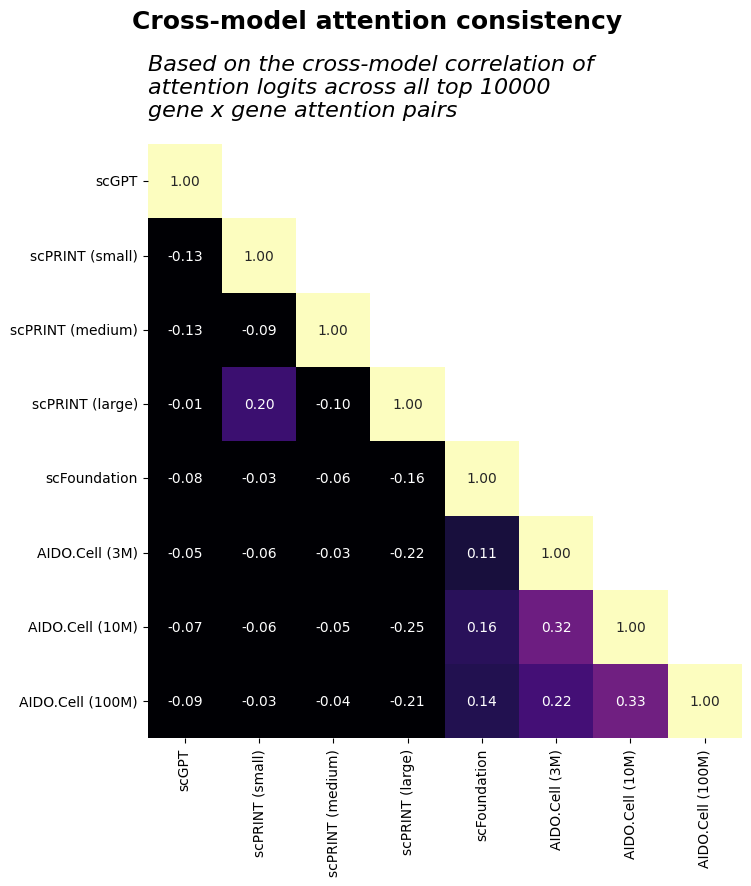

In [17]:
consensus_top_k = comparisons["cross_model_consensus_top_attentions"]

wide_consensus_top_k = (
    consensus_top_k.pivot(index = ["from_gene", "to_gene"], columns = "model", values = "attention")
    .reindex(columns=model_order)
)

cross_model_attention_corr = compute_correlation_matrix(wide_consensus_top_k.to_numpy())

plot_heatmap(
    cross_model_attention_corr,
    row_labels = wide_consensus_top_k.columns.tolist(),
    suptitle="Cross-model attention consistency",
    title=f"Based on the cross-model correlation of\nattention logits across all top {TOP_K}\ngene x gene attention pairs",
    cmap='magma',
    cbar=False,
    fmt='.2f',
    vmax=1,
    vmin=0,
    mask_upper_triangle=True,
    annot=True,
    square=True,
    suptitle_size=18,
    title_size=16,
    axis_title_size=16,
    title_fontstyle="italic",
    title_fontweight="normal",
    figsize=(9, 9)
)

plt.show()

In [18]:
n_genes = attended_embeddings.n_common_genes

model_x_layer_rank_agreement = compare_top_k_union_ranks(
    consensus_top_k,
    grouping_vars = ["model"],
    defining_vars = ["from_gene", "to_gene"],
    max_rank = n_genes ** 2,
    top_k = TOP_K,
    rank_col = "attention_rank"
)

# [0,1] low quantiles are more consistent (ranks in attent B | top in A)
raw_conditional_quantiles = (
    model_x_layer_rank_agreement
    .pivot(
        index = ["query_model"],
        columns = ["eval_model"],
        values = "median_quantile"
    )
    .reindex(index=model_order, columns=model_order)
)

# [0,1] -> [-1,1] with values near 1 being more consistent
conditional_quantiles = (0.5 + -1 * raw_conditional_quantiles)*2

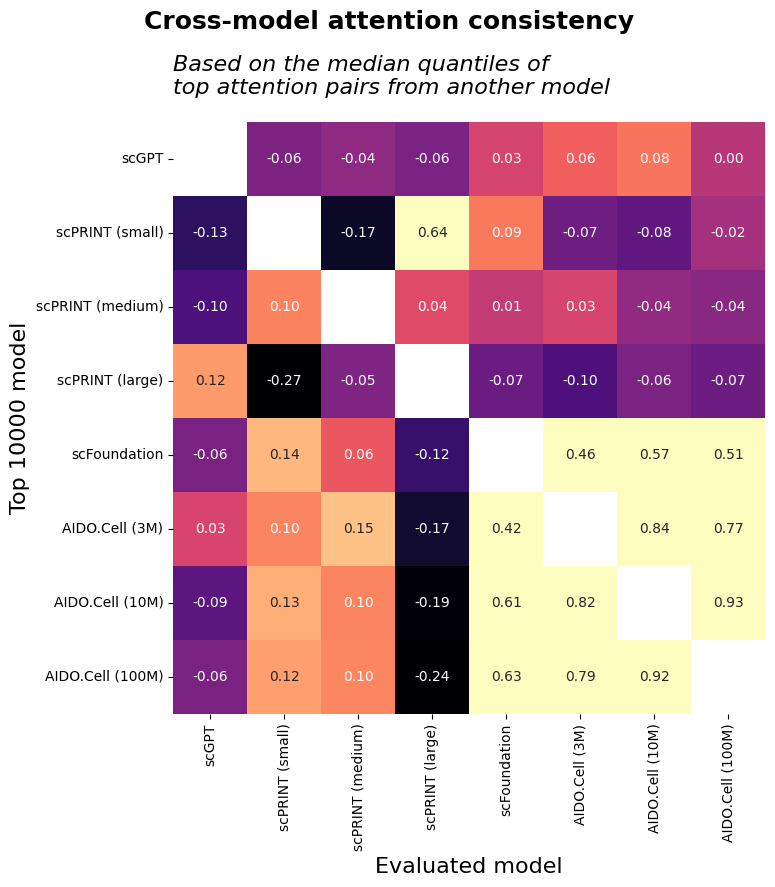

In [19]:
plot_heatmap(
    conditional_quantiles,
    row_labels = raw_conditional_quantiles.columns.tolist(),
    column_labels = raw_conditional_quantiles.index.tolist(),
    suptitle=f"Cross-model attention consistency",
    title=f"Based on the median quantiles of\ntop attention pairs from another model",
    xlabel = "Evaluated model",
    ylabel = f"Top {TOP_K} model",
    cmap='magma',
    cbar=False,
    fmt='.2f',
    vmax=0.2,
    vmin=-0.2,
    cbar_label='Rank aggreement',
    mask_upper_triangle=False,
    annot=True,
    square=True,
    suptitle_size=18,
    title_size=16,
    axis_title_size=16,
    title_fontstyle="italic",
    title_fontweight="normal",
    figsize=(9, 9)
)

plt.show()

## Summarize attention pairs as edgelist

In [20]:
from napistu_torch.evaluation.manager import RemoteEvaluationManager

In [21]:
select_query_layers = max_cross_model_layer_agreement.reset_index().value_counts(["query_model", "query_layer"]).iloc[0:3]
# look at the evaluation layers whose ranks most agree with the selected query layers
max_cross_model_layer_agreement.reset_index().merge(select_query_layers.reset_index(), on=['query_model', 'query_layer']).set_index(['query_model', 'query_layer']).sort_index()

eval_model  eval_layer  mean_quantile  \
query_model    query_layer                                                
AIDO.Cell (3M) 0            AIDO.Cell (100M)          12       0.214326   
               0             AIDO.Cell (10M)           1       0.116481   
               0                scFoundation           0       0.222043   
               0             scPRINT (large)           0       0.402092   
scFoundation   0            AIDO.Cell (100M)          13       0.235792   
               0             AIDO.Cell (10M)           1       0.230771   
               0              AIDO.Cell (3M)           0       0.208723   
               0                       scGPT           8       0.379654   
               0            scPRINT (medium)           0       0.417771   
               0             scPRINT (small)           0       0.416966   
scGPT          7            AIDO.Cell (100M)           7       0.388870   
               7             AIDO.Cell (10M)           4       0.369190   
               7              AIDO.Cell (3M)           5       0.326790   

                            median_quantile  min_quantile  max_quantile  \
query_model    query_layer                                                
AIDO.Cell (3M) 0                   0.040496      0.000002      0.999993   
               0                   0.039658      0.000005      0.999993   
               0                   0.102812      0.000002      0.999413   
               0                   0.361985      0.000083      0.997455   
scFoundation   0                   0.057217      0.000002      0.999993   
               0                   0.063936      0.000002      1.000000   
               0                   0.070401      0.000005      0.999491   
               0                   0.333176      0.000334      0.999548   
               0                   0.400346      0.000345      0.999162   
               0                   0.392814      0.000220      0.998891   
scGPT          7                   0.341706      0.000020      0.999814   
               7                   0.301105      0.000246      0.999949   
               7                   0.232020      0.000016      0.999955   

                             statistic        p_value  count  
query_model    query_layer                                    
AIDO.Cell (3M) 0             6361914.5   0.000000e+00      4  
               0             1149264.5   0.000000e+00      4  
               0             4235858.5   0.000000e+00      4  
               0            15470945.5  1.641986e-238      4  
scFoundation   0             5864238.0   0.000000e+00      6  
               0             6220293.5   0.000000e+00      6  
               0             4011821.0   0.000000e+00      6  
               0            13243081.0   0.000000e+00      6  
               0            16477528.5  1.170000e-189      6  
               0            16264143.5  3.105760e-199      6  
scGPT          7            14111552.0  3.578573e-261      3  
               7            12634985.0   0.000000e+00      3  
               7             9874040.0   0.000000e+00      3

In [22]:
# look at the topK attentions for the selected layers
top_k_select_attentions = (
    cross_model_top_attentions.merge(
        (
            select_query_layers.reset_index()
            .drop(columns = ["count"])
            .rename(columns = {"query_model" : "model", "query_layer" : "layer"})
        ),
        on=["model", "layer"],
        how = "inner"
    )
    .query("attention_rank <= @TOP_K")
    .set_index(["model", "layer"])
    .sort_values("attention_rank")
    .sort_index()
)

# filter to just the from-to genes for the top attentions
top_k_select_attention_gene_edgelist = top_k_select_attentions[["from_gene", "to_gene"]].drop_duplicates()

In [23]:
# get the indices in the NapistuData object for the top attention pairs
gene_to_vertex_map = map_identifiers_to_vertex_names(attended_embeddings.common_gene_ids, species_identifiers, name_to_sid_map)

def add_vertex_names_to_edgelist(
    top_k_select_attention_gene_edgelist,
    gene_to_vertex_map
):

    top_k_with_ids = (
        top_k_select_attention_gene_edgelist
        .merge(
            (
                gene_to_vertex_map
                .rename(columns = {"ensembl_gene" : "from_gene", "name" : "from_vertex"})
                .drop(columns = ["s_id"])
            ),
            on = "from_gene",
            how = "left"
        )
        .merge(
            gene_to_vertex_map
            .rename(columns = {"ensembl_gene" : "to_gene", "name" : "to_vertex"})
            .drop(columns = ["s_id"]),
            on = "to_gene",
            how = "left"
        )
    )

    # drop NAs and log
    invalid_edges = top_k_with_ids.isna().any(axis = 1)
    if invalid_edges.sum() > 0:
        percent_invalid = (invalid_edges.sum() / len(top_k_with_ids)) * 100
        logger.warning(f"Dropping {invalid_edges.sum()} edges ({percent_invalid:.2f}%) which could not be mapped to vertices")

    return top_k_with_ids.loc[~invalid_edges]

focused_attention_edgelist = add_vertex_names_to_edgelist(
    top_k_select_attention_gene_edgelist,
    gene_to_vertex_map
)

NameError: name 'map_identifiers_to_vertex_names' is not defined

## Load models

In [ ]:
evaluation_manager = RemoteEvaluationManager.from_huggingface(
    "seanhacks/edge_prediction_mlp_256e",
    data_store_dir = STORE_DIR
)
model = evaluation_manager.load_model_from_checkpoint()
napistu_data = evaluation_manager.load_napistu_data()


In [ ]:
# find the indices of the edges in the NapistuData object
edge_indices = napistu_data.get_edge_indices(focused_attention_edgelist, "from_vertex", "to_vertex")
task = model.task
predictions = task.predict_edge_scores(
    data=napistu_data,
    edge_index=edge_indices,
)

focused_attention_edgelist["prediction"] = predictions
focused_attention_edgelist["direct_edge_exists"] = napistu_data.has_edges(edge_indices)

In [ ]:
all_topk_attention_gene_edgelist = (
    comparisons["cross_model_x_layer_top_attentions"]
    .query("attention_rank <= @TOP_K")
)

distinct_topk_attention_gene_edgelist = all_topk_attention_gene_edgelist[["from_gene", "to_gene"]].drop_duplicates()

distinct_topk_attention_gene_edgelist = add_vertex_names_to_edgelist(
    distinct_topk_attention_gene_edgelist,
    gene_to_vertex_map
)

In [ ]:
edge_indices = napistu_data.get_edge_indices(distinct_topk_attention_gene_edgelist, "from_vertex", "to_vertex")
task = model.task
predictions = task.predict_edge_scores(
    data=napistu_data,
    edge_index=edge_indices,
)

distinct_topk_attention_gene_edgelist["prediction"] = predictions
distinct_topk_attention_gene_edgelist["direct_edge_exists"] = napistu_data.has_edges(edge_indices)

In [ ]:
curated_top_edges = all_topk_attention_gene_edgelist.merge(
    distinct_topk_attention_gene_edgelist[["from_gene", "to_gene", "prediction", "direct_edge_exists"]],
    on = ["from_gene", "to_gene"],
    how = "left"
)

In [ ]:
direct_edge_rate = (
    curated_top_edges.value_counts(["model", "layer", "direct_edge_exists"])
    .reset_index()
    .pivot(index = ["model", "layer"], columns = "direct_edge_exists", values = "count")
    .fillna(0)
    .assign(true_fraction = lambda x: x[True] / x.sum(axis = 1))
    .reset_index()
    .assign(model_name = lambda x: pd.Categorical(
        x['model'], 
        categories=model_order, 
        ordered=True
    ))
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.lineplot(
    data=direct_edge_rate, 
    x='layer', 
    y='true_fraction', 
    hue='model_name',
    palette='muted',  # muted palette
    marker='o',
    markersize=8,
    linewidth=1,
    linestyle='--',
    alpha=0.7,
    ax=ax
)

ax.set_xlabel('Layer')
ax.set_ylabel('True Fraction')
ax.set_title('Direct Edge Rate by Layer and Model')
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Set x-axis to show only even integers
max_layer = direct_edge_rate['layer'].max()
ax.set_xticks(range(0, max_layer + 1, 2))  # 0, 2, 4, 6, ...

plt.tight_layout()
plt.show()

In [ ]:
average_edge_prediction = (
    curated_top_edges
    .groupby(["model", "layer"])["prediction"]
    .median()
    .reset_index()
    .assign(model_name = lambda x: x["model"])
    .assign(model_name = lambda x: pd.Categorical(
        x['model_name'], 
        categories=model_order, 
        ordered=True
    ))
)

# average predictions for the layers with the highest cross-model rank agreement
max_cross_model_layer_agreement_w_edge_predictions = (
    select_query_layers
    .reset_index()
    .merge(
        average_edge_prediction
        .rename(columns = {"model" : "query_model", "layer" : "query_layer", "prediction" : "query_avg_edge_prediction"}),
        on = ["query_model", "query_layer"],
        how = "inner"
    )
)

fig, ax = plt.subplots(figsize=(7, 4))

# Create the main plot
sns.lineplot(
    data=average_edge_prediction, 
    x='layer', 
    y='prediction', 
    hue='model_name',
    palette='muted',
    marker='o',
    markersize=8,
    linewidth=1,
    linestyle='--',
    alpha=0.7,
    ax=ax
)

# Get the color mapping from the plot
colors = {line.get_label(): line.get_color() for line in ax.get_lines()}

# Convert dataframe to list of dicts for arrows
highlight_points = max_cross_model_layer_agreement_w_edge_predictions[
    ['query_model', 'query_layer', 'query_avg_edge_prediction']
].rename(columns={
    'query_model': 'model',
    'query_layer': 'layer', 
    'query_avg_edge_prediction': 'value'
}).to_dict('records')

for point in highlight_points:
    model_nice_name = point['model']
    color = colors[model_nice_name]
    
    # Add shorter arrow pointing down at the point
    ax.annotate('', 
                xy=(point['layer'], point['value']),  # point to
                xytext=(point['layer'], point['value'] + 0.02),  # shorter arrow
                arrowprops=dict(arrowstyle='->', color=color, lw=2.5, alpha=0.9))

ax.set_xlabel('Layer')
ax.set_ylabel('Average Edge Score')
ax.set_title('Average Edge Score by Layer and Model')
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Set x-axis to show only even integers
max_layer = average_edge_prediction['layer'].max()
ax.set_xticks(range(0, max_layer + 1, 2))

# Expand y-axis limits
y_min = average_edge_prediction['prediction'].min()
y_max = average_edge_prediction['prediction'].max()
y_range = y_max - y_min
ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.1 * y_range)

plt.tight_layout()
plt.show()


## What do the high scoring edges represent?

In [ ]:
from napistu.identifiers import construct_cspecies_identifiers
from napistu.genomics.gsea import edgelist_gsea, GenesetCollection
from napistu.network.edgelist import Edgelist
from itertools import chain


TOP_MODEL_NAME = "scGPT"
TOP_MODEL_LAYER = 7

# load the graph that the NapistuData object was created from
napistu_graph = napistu_data_store.load_napistu_graph()

In [ ]:
# create gmt-style genesets 
geneset_collection = GenesetCollection("Homo sapiens")
geneset_collection.add_gmts("wikipathways")
# add sc_ids to the species systematic
cspecies_identifiers = construct_cspecies_identifiers(species_identifiers, name_to_sid_map.rename(columns={"name" : "sc_id"}))
# dict genes set names -> vertex IDs (sc_ids)
genesets = geneset_collection.get_gmt_w_napistu_ids(cspecies_identifiers, "sc_id")
# define all vertices associated with at least one geneset
all_vertices_w_a_geneset = list(set(chain.from_iterable(genesets.values())))


In [ ]:
edgelist = Edgelist(
    cross_model_top_attentions
    .query("model == @TOP_MODEL_NAME and layer == @TOP_MODEL_LAYER and attention_rank <= @TOP_K")
    .merge(distinct_topk_attention_gene_edgelist, on = ["from_gene", "to_gene"])
    .query("from_vertex in @all_vertices_w_a_geneset and to_vertex in @all_vertices_w_a_geneset")
    .query("from_vertex != to_vertex")
    .rename(columns = {"from_vertex" : "from", "to_vertex" : "to"})
)
# ~2,500 edges

In [ ]:
#results = edgelist_gsea(
#    edgelist,
#    genesets,
#    graph=napistu_graph,
#    enrichment_test="binomial",
#    universe_vertex_names = all_vertices_w_a_geneset,
#    universe_observed_only = False,
#    verbose=True,
#)

